# Grid Bedmap3 point data and detrend
## Author: Michael Field
## Last updated: Feb 12 2025

This is workflow intakes Bedmap3 point data and grids it onto the Bedmap3 gridded product grid. This is an alternative to the Bedmap3 summarized points and thus can be used to grid at finer resolutions and change detrending for simulation purposes.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import verde as vd
from pathlib import Path
import os
from tqdm.auto import tqdm
import geopandas as gpd
from numba import njit, prange
from numba_progress import ProgressBar

import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append('./src')

from utilities import *
from block_statistics import *

In [2]:
def collect_files(path, verbose=False):
    """
    Collect Bedmap3 point files

    Args:
        path : path to Bedmap1/2/3 directory
        verbose : if True print files
    Outputs:
        DataFrame with surface, thickness, bed, lat, lon
    """
    total = 0
    for item in os.scandir(path):
        if item.name.endswith('.csv'):
            total += 1
    
    dfs = []
    
    for i, item in tqdm(enumerate(os.scandir(path)), total=total):
        if item.name.endswith('.csv'):
            if verbose==True:
                print(item.path)
            dfs.append(pd.read_csv(item.path, header=18))

    if len(dfs)==1:
        df = dfs[0]
    else:
        df = pd.concat(dfs)
    df = df.rename(columns=rename_dict)
    df = df[['surface', 'thickness', 'bed', 'lat', 'lon']]
    df = df.replace(-9999, np.nan)
    
    return df

In [3]:
# base_path = Path('/Users/ls-gatorglaciology/Documents/raw_data')
base_path = Path('D:/')
bm1path = Path(base_path/'bedmap/BEDMAP1')
bm2path = Path(base_path/'bedmap/BEDMAP2')
bm3path = Path(base_path/'bedmap/BEDMAP3')
bmgrid_path = Path(base_path/'bedmap/bedmap3.nc')
stream_path = Path(base_path/'bedmap/bm3_streamlines_pt/bm3_streamlines_pt.shp')
coldex_path = Path(base_path/'bedmap/2023_Antarctica_BaslerMKB.csv')
bmach_path = Path(base_path/'bedmachine/BedMachineAntarctica-v3.nc')

rename_dict = {
    'surface_altitude (m)' : 'surface',
    'land_ice_thickness (m)' : 'thickness',
    'bedrock_altitude (m)' : 'bed',
    'longitude (degree_east)' : 'lon',
    'latitude (degree_north)' : 'lat'
}

In [4]:
print('collecting files')
bm1 = collect_files(bm1path)
bm2 = collect_files(bm2path)
bm3 = collect_files(bm3path)

df = pd.concat([bm1, bm2, bm3])

del(bm1)
del(bm2)
del(bm3)

x_coords, y_coords = geo2ant(df['lat'], df['lon'])
df['x'] = x_coords
df['y'] = y_coords

msk = (df['thickness'].isna()==True) & (df['surface'].isna()==False) & (df['bed'].isna()==False)
df.loc[msk, 'thickness'] = df.loc[msk, 'surface'] - df.loc[msk, 'bed']

df = df.loc[df['thickness'].isna()==False]

# add new COLDEX data
coldex = pd.read_csv(coldex_path)

x_coords, y_coords = geo2ant(coldex['LAT'], coldex['LON'])
coldex['x'] = x_coords
coldex['y'] = y_coords

coldex = coldex.rename(columns={'LAT' : 'lat', 'LON' : 'lon', 'THICK' : 'thickness', 'SURFACE' : 'surface', 'BOTTOM' : 'bed'})
coldex = coldex[['surface', 'thickness', 'bed', 'lat', 'lon', 'x', 'y']]

df = pd.concat([df, coldex])

collecting files


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

In [5]:
ds = xr.open_dataset(bmgrid_path)
xx, yy = np.meshgrid(ds.x, ds.y)

In [6]:
ds.x.values

array([-3333250., -3332750., -3332250., ...,  3332250.,  3332750.,
        3333250.], shape=(13334,), dtype=float32)

In [7]:
ds.y.values

array([ 3333250.,  3332750.,  3332250., ..., -3332250., -3332750.,
       -3333250.], shape=(13334,), dtype=float32)

In [8]:
xbin_edges = ds.x.values - 250
xbin_edges = np.append(xbin_edges, ds.x.values[-1]+250)
xbin_edges

array([-3333500., -3333000., -3332500., ...,  3332500.,  3333000.,
        3333500.], shape=(13335,), dtype=float32)

In [9]:
ybin_edges = ds.y.values + 250
ybin_edges = np.append(ybin_edges, ds.y.values[-1]-250)
ybin_edges

array([ 3333500.,  3333000.,  3332500., ..., -3332500., -3333000.,
       -3333500.], shape=(13335,), dtype=float32)

# Do block reduction in parallel

In [10]:
coords = (df.x.values, df.y.values)
thickness = df.thickness.values

In [23]:
result, center_coords = block_reduce_par(xbin_edges, ybin_edges, coords, thickness, metrics=['median', 'std'])

  0%|          | 0/10872 [00:00<?, ?it/s]

In [12]:
# delete DataFrame to save memory, remove if you want to save point data
del(df)

In [24]:
x_center, y_center = center_coords

np.allclose(ds.x.values, x_center)

True

# Basic QC - remove grid cells with > 300 m difference from Bedmap3 gridded ice thickness or stdev > 300 m

In [25]:
median = result[0].astype(np.float32)
stdev = result[1].astype(np.float32)

In [26]:
bad_msk = (stdev>300) | (np.abs(ds.ice_thickness.values-median)>300)
x_bad = xx[bad_msk]
y_bad = yy[bad_msk]

print(f'{x_bad.size:,} bad points, {x_bad.size/np.count_nonzero(~np.isnan(median))*100:.2f}% of conditioning data')

53,537 bad points, 1.36% of conditioning data


In [27]:
# filter bad
median = np.where(bad_msk, np.nan, median)
stdev = np.where(bad_msk, np.nan, stdev)

Text(0.5, 1.0, 'Bad grid cells')

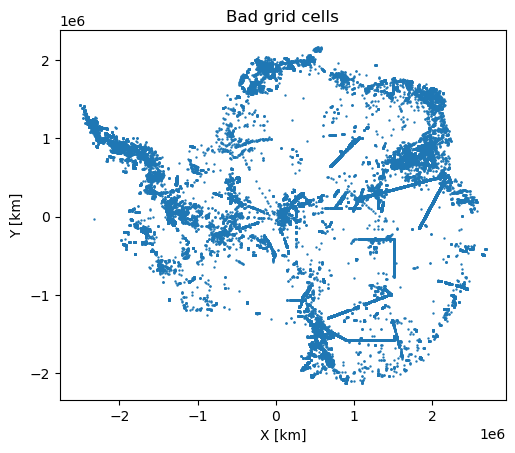

In [17]:
plt.scatter(x_bad, y_bad, s=0.5)
plt.axis('scaled')
plt.xlabel('X [km]')
plt.ylabel('Y [km]')
plt.title('Bad grid cells')
#plt.savefig(Path('../figures/bad_grid_cells.png'), dpi=300, bbox_inches='tight')

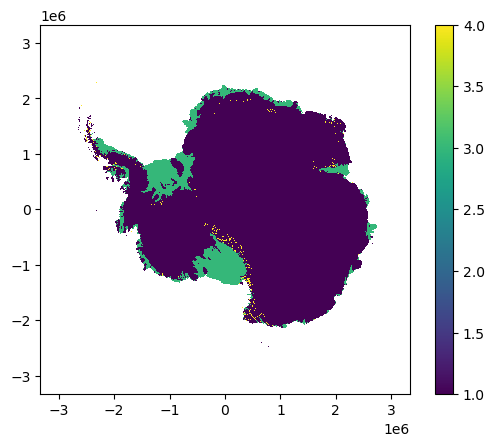

In [18]:
plt.pcolormesh(ds.x, ds.y, ds.mask)
plt.axis('scaled')
plt.colorbar()
plt.show()

In [19]:
np.unique(ds.mask.values)

array([ 1.,  2.,  3.,  4., nan], dtype=float32)

# Add exposed bed to conditioning data

In [20]:
thick_cond = np.where(ds.mask.values==4, 0, median)

bed_cond = ds.surface_topography.values - thick_cond

# Make a trend

Adjust the damping to change smoothness

In [21]:
%%time

xx, yy = np.meshgrid(ds.x, ds.y)

cond_msk = ~np.isnan(bed_cond)
x_cond = xx[cond_msk]
y_cond = yy[cond_msk]
data_cond = bed_cond[cond_msk]

mask = (ds.mask.values==1) | (ds.mask.values==2) | (ds.mask.values==4)

# randomly downsample coordinates for computational reasons
n_samples = 5_000
rng = np.random.default_rng(0)
inds = rng.integers(0, x_cond.shape[0]-1, n_samples)
x_cond_sample = x_cond[inds]
y_cond_sample = y_cond[inds]
data_cond_sample = data_cond[inds]

# downsample data for fitting a trend
cond_coords = np.array([x_cond_sample, y_cond_sample]).T
trend = spline_interp_msk(cond_coords, data_cond_sample, xx, yy, mask, damping=1e-7).astype(np.float32)

res_cond = bed_cond - trend

CPU times: total: 1h 28min 38s
Wall time: 5min 59s


In [22]:
x_cond[::100].size

40911

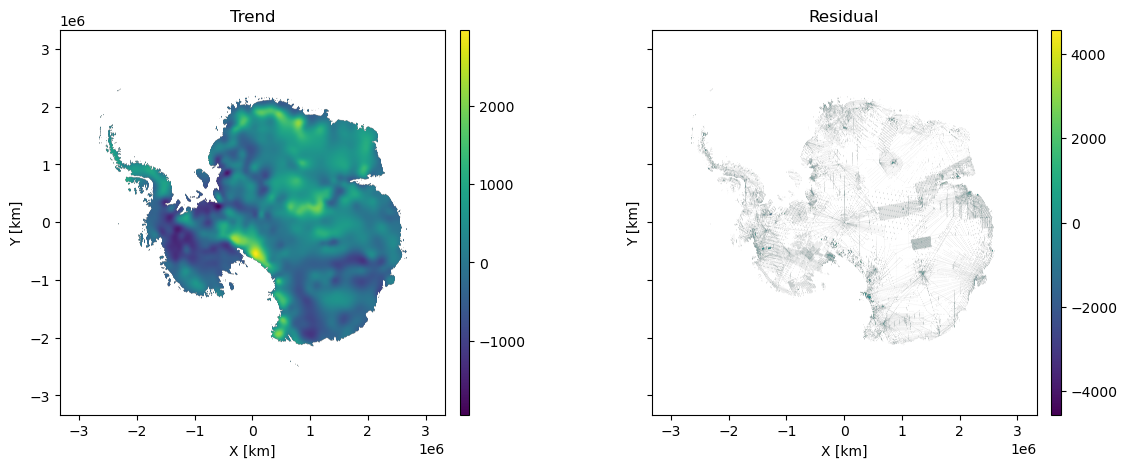

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(14,5), sharey=True)
ax = axs[0]
im = ax.imshow(trend, extent=(ds.x.values.min(), ds.x.values.max(), ds.y.values.min(), ds.y.values.max()))
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Trend')

ax = axs[1]
im = ax.imshow(res_cond, extent=(ds.x.values.min(), ds.x.values.max(), ds.y.values.min(), ds.y.values.max()))
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Residual')
#plt.savefig(Path('../figures/trend_residual.png'), dpi=300, bbox_inches='tight')
plt.show()

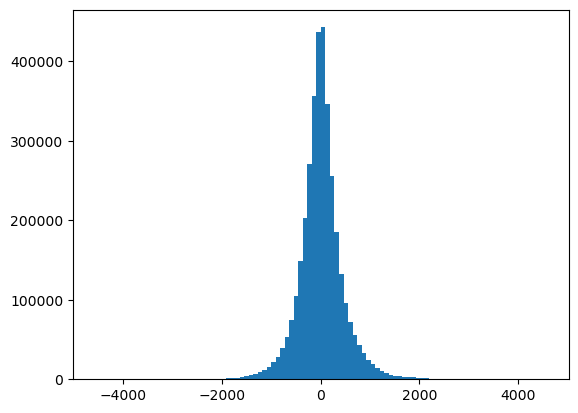

In [24]:
plt.hist(res_cond.flatten(), bins=100)
plt.show()

# Optionally make streamlines

In [25]:
pts = gpd.read_file(stream_path)

coords = pts.get_coordinates()
coords = (np.rint(coords['x'].values), np.rint(coords['y'].values))
thick = pts.thick.values

stream_thick = xy_into_grid(ds.x.values, ds.y.values, coords, thick).astype(np.float32)

  0%|          | 0/258721 [00:00<?, ?it/s]

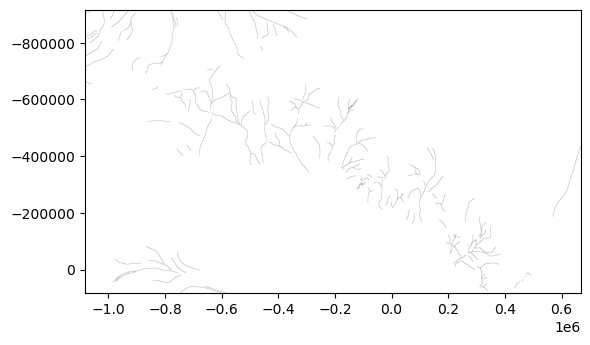

In [26]:
plt.imshow(stream_thick[6500:8500,4500:8000], extent=(ds.x.values[4500], ds.x.values[8000], ds.y.values[6500], ds.y.values[8500]))
plt.show()

# Add bedmachine geoid

In [27]:
%%time

# Interpolate BedMachine geoid onto Bedmap3
bmach = xr.open_dataset(bmach_path)

xx_bmach, yy_bmach = np.meshgrid(bmach.x, bmach.y)

linear = vd.KNeighbors(k=1)
linear.fit((xx_bmach, yy_bmach), bmach.geoid.values)
preds = linear.predict((xx, yy)).astype(np.float32)

CPU times: total: 5min 28s
Wall time: 5min 38s


# Save just thickness array

In [30]:
thick_cond = thick_cond.astype(np.float32)

In [32]:
np.save(Path('processed_data/bedmap3_raw_thick_compilation.npy'), thick_cond)

# Find minimum distance to conditioning data

In [37]:
%%time

min_dist = min_dist_from_mask(xx, yy, cond_msk)

CPU times: total: 21min 46s
Wall time: 22min 24s


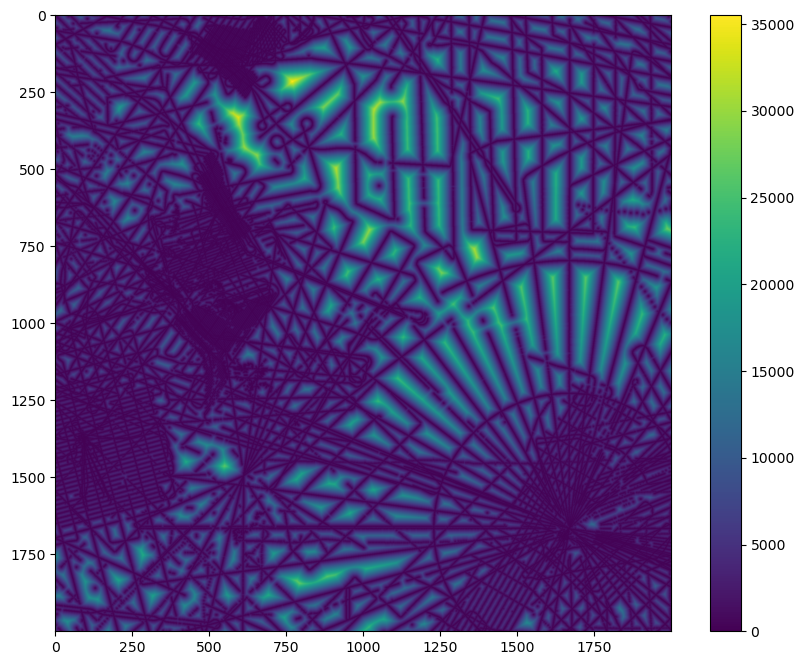

In [42]:
plt.figure(figsize=(10,8))
plt.imshow(min_dist[5000:7000,5000:7000])
plt.colorbar()
plt.show()

# Save modified xarray.Dataset

In [44]:
ds['geoid'] = (('y', 'x'), preds.astype(np.float32))
ds['thick_cond'] = (('y', 'x'), thick_cond.astype(np.float32))
ds['stdev'] = (('y', 'x'), stdev.astype(np.float32))
ds['stream_thick'] = (('y', 'x'), stream_thick.astype(np.float32))
ds['trend'] = (('y', 'x'), trend.astype(np.float32))
ds['min_dist'] = (('y', 'x'), min_dist.astype(np.float32))

ds

<xarray.Dataset> Size: 9GB
Dimensions:                 (x: 13334, y: 13334)
Coordinates:
  * x                       (x) float32 53kB -3.333e+06 -3.333e+06 ... 3.333e+06
  * y                       (y) float32 53kB 3.333e+06 3.333e+06 ... -3.333e+06
Data variables: (12/14)
    surface_topography      (y, x) float32 711MB nan nan nan nan ... nan nan nan
    bed_uncertainty         (y, x) float32 711MB ...
    bed_topography          (y, x) float32 711MB ...
    mask                    (y, x) float32 711MB nan nan nan nan ... nan nan nan
    ice_thickness           (y, x) float32 711MB nan nan nan nan ... nan nan nan
    thickness_survey_count  (y, x) float32 711MB ...
    ...                      ...
    geoid                   (y, x) float32 711MB -1.0 -1.0 -1.0 ... -19.0 -19.0
    thick_cond              (y, x) float32 711MB nan nan nan nan ... nan nan nan
    stdev                   (y, x) float32 711MB nan nan nan nan ... nan nan nan
    stream_thick            (y, x) float32 711MB nan nan nan nan ... nan nan nan
    trend                   (y, x) float32 711MB nan nan nan nan ... nan nan nan
    min_dist                (y, x) float32 711MB 1.441e+06 ... 2.077e+06
Attributes: (12/26)
    crs:                    EPSG:3031
    title:                  BEDMAP3 - Ice thickness, bed and surface elevatio...
    summary:                We present here Bedmap3, the latest suite of grid...
    keywords:               Antarctica,BEDMAP,Elevation,Ice thickness
    Conventions:            ACDD-1.3, CF-1.8
    citation:               Pritchard, H., Fretwell, P., Fremand, A., Bodart,...
    ...                     ...
    time_coverage_end:      2024-11-01
    geospatial_lon_min:     -180
    geospatial_lon_max:     180
    geospatial_lat_min:     -90
    geospatial_lat_max:     -60
    geospatial_bounds_crs:  EPSG:4326

In [45]:
ds.to_netcdf(Path('processed_data/bedmap3_mod_500.nc'))

In [46]:
ground_ice_msk = (ds.mask == 1) | (ds.mask == 2)
print(f'{np.count_nonzero(np.isnan(ds.thick_cond.values) & ground_ice_msk):,} grid cells to simulate at 500 m resolution')

44,813,674 grid cells to simulate at 500 m resolution


# Coarsen to 1000 m and save

In [47]:
%%time

# coarsen to 1 km resolution
ds_coarse = ds.coarsen(x=2, y=2, boundary='trim').median()
ds_coarse['mask'] = (('y', 'x'), np.where(np.isnan(ds_coarse.mask.values), np.nan, np.rint(ds_coarse.mask.values).astype(np.int32)))

coarse_bed = np.where(ds_coarse.mask.values==4, ds_coarse.surface_topography.values, ds_coarse.bed_topography.values)
coarse_bed = np.where(coarse_bed > ds_coarse.surface_topography.values, ds_coarse.surface_topography, coarse_bed)
ds_coarse['bed_topography'] = (('y', 'x'), coarse_bed)

ds_coarse['ice_thickness'] = (('y', 'x'), ds_coarse.surface_topography.values - coarse_bed)

ds_coarse

CPU times: total: 7min 49s
Wall time: 8min 8s


<xarray.Dataset> Size: 2GB
Dimensions:                 (y: 6667, x: 6667)
Coordinates:
  * x                       (x) float32 27kB -3.333e+06 -3.332e+06 ... 3.333e+06
  * y                       (y) float32 27kB 3.333e+06 3.332e+06 ... -3.333e+06
Data variables: (12/14)
    surface_topography      (y, x) float32 178MB nan nan nan nan ... nan nan nan
    bed_uncertainty         (y, x) float32 178MB nan nan nan nan ... nan nan nan
    bed_topography          (y, x) float32 178MB nan nan nan nan ... nan nan nan
    mask                    (y, x) float64 356MB nan nan nan nan ... nan nan nan
    ice_thickness           (y, x) float32 178MB nan nan nan nan ... nan nan nan
    thickness_survey_count  (y, x) float32 178MB nan nan nan nan ... nan nan nan
    ...                      ...
    geoid                   (y, x) float32 178MB -1.0 -1.0 -1.0 ... -19.0 -19.0
    thick_cond              (y, x) float32 178MB nan nan nan nan ... nan nan nan
    stdev                   (y, x) float32 178MB nan nan nan nan ... nan nan nan
    stream_thick            (y, x) float32 178MB nan nan nan nan ... nan nan nan
    trend                   (y, x) float32 178MB nan nan nan nan ... nan nan nan
    min_dist                (y, x) float32 178MB 1.441e+06 ... 2.077e+06
Attributes: (12/26)
    crs:                    EPSG:3031
    title:                  BEDMAP3 - Ice thickness, bed and surface elevatio...
    summary:                We present here Bedmap3, the latest suite of grid...
    keywords:               Antarctica,BEDMAP,Elevation,Ice thickness
    Conventions:            ACDD-1.3, CF-1.8
    citation:               Pritchard, H., Fretwell, P., Fremand, A., Bodart,...
    ...                     ...
    time_coverage_end:      2024-11-01
    geospatial_lon_min:     -180
    geospatial_lon_max:     180
    geospatial_lat_min:     -90
    geospatial_lat_max:     -60
    geospatial_bounds_crs:  EPSG:4326

In [48]:
ds_coarse.to_netcdf(Path('processed_data/bedmap3_mod_1000.nc'))

In [49]:
ground_ice_msk = (ds_coarse.mask == 1) | (ds_coarse.mask == 2)
print(f'{np.count_nonzero(np.isnan(ds_coarse.thick_cond.values) & ground_ice_msk):,} grid cells to simulate at 1000 m resolution')

10,300,532 grid cells to simulate at 1000 m resolution


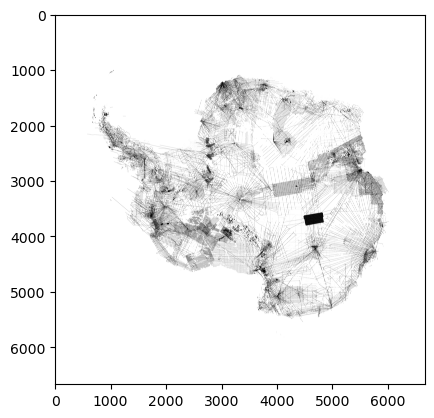

In [50]:
plt.imshow(~np.isnan(ds_coarse.thick_cond.values), cmap='binary')
plt.show()